In [3]:
import pandas as pd

# 파일 경로 설정
file_path = 'pos_data_전처리완료_final.parquet'

print("데이터 로딩을 시작합니다. 약 1억 행의 데이터이므로 메모리 사용량에 주의하세요...")

try:
    # 전체 데이터를 df_pos로 로드
    df_pos = pd.read_parquet(file_path)
    print("데이터 로드 성공!")
    
    # 데이터 정보 확인
    print(f"\n전체 데이터 행 수: {len(df_pos):,}")
    display(df_pos.head())
    
    print("\n--- 데이터 기본 정보 ---")
    print(df_pos.info())
    
    print("\n--- 컬럼별 결측치 확인 ---")
    print(df_pos.isnull().sum())
    
except MemoryError:
    print("\n[오류] 메모리 부족으로 전체 데이터를 로드할 수 없습니다. RAM 용량을 확인하거나 샘플링 또는 청크 방식을 사용하세요.")


데이터 로딩을 시작합니다. 약 1억 행의 데이터이므로 메모리 사용량에 주의하세요...
데이터 로드 성공!

전체 데이터 행 수: 100,085,071


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키
0,20250523,84531,64139,2,26651,314952,1.0,500.0,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기,2025-05-23 08:45:31,5,21,23,8,금,64139_2_26651
1,20250523,105724,52657,1,48727,314954,10.0,45000.0,K)MIIX 믹스(릴 하이브리드),담배,국산담배,KT&G(전자담배용 담배),2025-05-23 10:57:24,5,21,23,10,금,52657_1_48727
2,20250523,105724,52657,1,48727,314952,10.0,5000.0,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기,2025-05-23 10:57:24,5,21,23,10,금,52657_1_48727
3,20250523,84531,64139,2,26651,314983,1.0,4500.0,K)MIIX 아이스더블,담배,국산담배,KT&G(전자담배용 담배),2025-05-23 08:45:31,5,21,23,8,금,64139_2_26651
4,20250523,83823,50134,1,67971,314988,1.0,4500.0,K)에쎄 히말라야1mg,담배,국산담배,KT&G(일반담배),2025-05-23 08:38:23,5,21,23,8,금,50134_1_67971



--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100085071 entries, 0 to 100085070
Data columns (total 19 columns):
 #   Column   Dtype         
---  ------   -----         
 0   영업일자     int64         
 1   판매시분초    int64         
 2   점포코드     int64         
 3   POS번호    int64         
 4   거래번호     int64         
 5   상품코드     object        
 6   매출수량     float32       
 7   매출금액     float32       
 8   상품명      object        
 9   상품대분류명   object        
 10  상품중분류명   object        
 11  상품소분류명   object        
 12  판매시간_dt  datetime64[ns]
 13  판매월      Int8          
 14  판매주      Int8          
 15  판매일      Int8          
 16  판매시간대    Int8          
 17  판매요일     category      
 18  거래_고유키   object        
dtypes: Int8(4), category(1), datetime64[ns](1), float32(2), int64(5), object(6)
memory usage: 10.5+ GB
None

--- 컬럼별 결측치 확인 ---
영업일자       0
판매시분초      0
점포코드       0
POS번호      0
거래번호       0
상품코드       0
매출수량       0
매출금액       0
상품명        0
상품대분류명   

## '매출금액' 이상치 확인

In [4]:
df_pos['매출금액'].describe()

count    1.000851e+08
mean     3.322248e+03
std      2.603010e+05
min     -1.300000e+09
25%      1.500000e+03
50%      2.300000e+03
75%      4.500000e+03
max      1.300000e+09
Name: 매출금액, dtype: float64

Q3(75% 지점): 4,500원
Q3 초과 데이터 수: 15,554,682건 (전체의 15.54%)

--- Q3 초과 구간 수치 분포 ---
count     1.555468e+07
mean      1.004241e+04
std       4.671044e+05
min       4.501000e+03
50%       6.900000e+03
75%       9.600000e+03
90%       1.500000e+04
99%       4.800000e+04
99.9%     1.350000e+05
99.99%    4.950000e+05
max       1.300000e+09
Name: 매출금액, dtype: float64


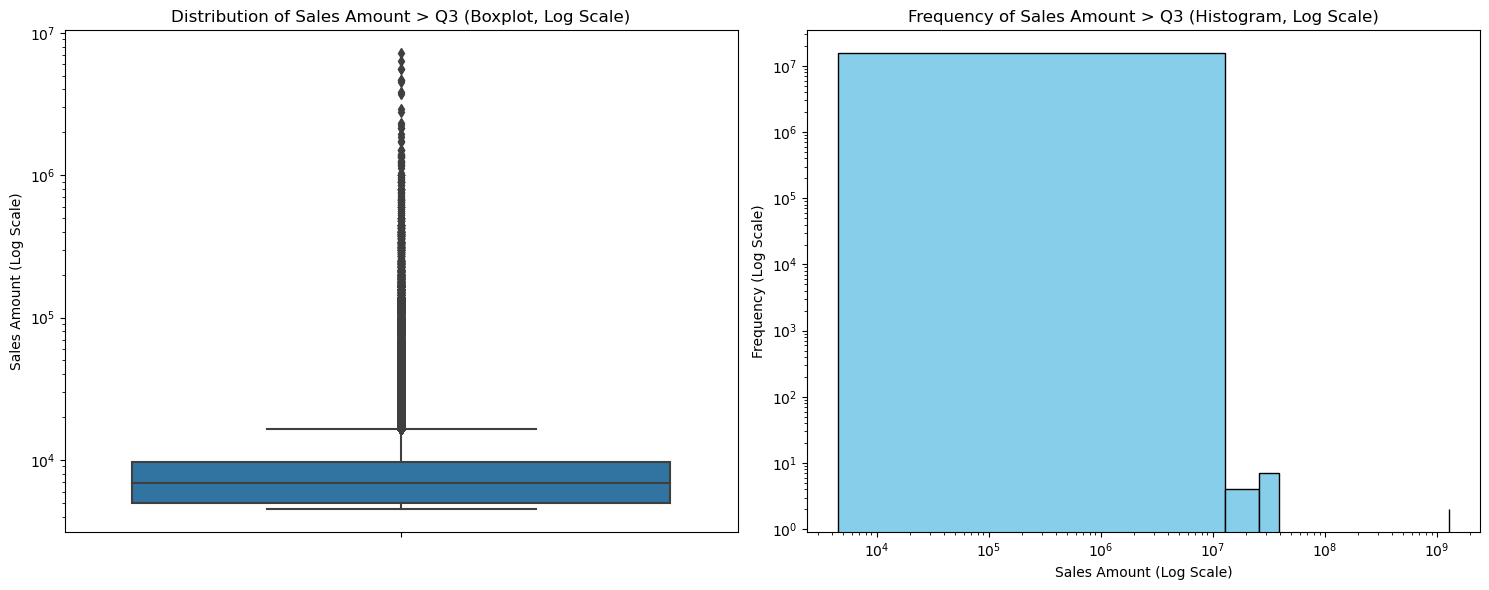

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Q3 값 설정 (이전 describe 결과 기반)
q3 = df_pos['매출금액'].quantile(0.75)
print(f"Q3(75% 지점): {q3:,.0f}원")

# 2. Q3를 초과하는 데이터 필터링
df_over_q3 = df_pos[df_pos['매출금액'] > q3]

print(f"Q3 초과 데이터 수: {len(df_over_q3):,}건 (전체의 {len(df_over_q3)/len(df_pos)*100:.2f}%)")

# 3. 수치적 분포 확인 (상위 1%, 0.1%, 0.01% 등 극단값 위주)
print("\n--- Q3 초과 구간 수치 분포 ---")
print(df_over_q3['매출금액'].describe(percentiles=[.5, .75, .9, .99, .999, .9999]))

# 4. 시각적 분포 확인
plt.figure(figsize=(15, 6))

# (1) Boxplot: 전체적인 퍼짐 정도 확인 (샘플링 100만 건)
plt.subplot(1, 2, 1)
sns.boxplot(y=df_over_q3['매출금액'].sample(n=min(1000000, len(df_over_q3))))
plt.yscale('log')  # 극단값 때문에 로그 스케일 필수
plt.title('Distribution of Sales Amount > Q3 (Boxplot, Log Scale)')
plt.ylabel('Sales Amount (Log Scale)')

# (2) Histogram: 구간별 빈도 확인
plt.subplot(1, 2, 2)
plt.hist(df_over_q3['매출금액'], bins=100, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.title('Frequency of Sales Amount > Q3 (Histogram, Log Scale)')
plt.xlabel('Sales Amount (Log Scale)')
plt.ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

## 객단가(매출금액/매출수량) 확인

객단가 계산 및 분포 확인을 시작합니다...

--- 객단가(Unit Price) 수치 요약 ---
count     1.000851e+08
mean      2.689555e+03
std       4.914383e+03
min       1.000000e+00
25%       1.300000e+03
50%       2.000000e+03
75%       3.500000e+03
95%       4.900000e+03
99%       1.080000e+04
99.9%     3.900000e+04
99.99%    1.199000e+05
max       1.300000e+07
Name: 객단가, dtype: float64

--- 객단가 상위 20개 항목 (고가 상품 혹은 오류 확인) ---


,상품명,상품대분류명,매출수량,매출금액,객단가
46820579,윌리엄)글렌피딕 40년,양주와인,-100.0,-1.300000e+09,13000000.0
46820615,윌리엄)글렌피딕 40년,양주와인,100.0,1.300000e+09,13000000.0
46820580,윌리엄)글렌피딕 40년,양주와인,100.0,1.300000e+09,13000000.0
46820616,윌리엄)글렌피딕 40년,양주와인,-100.0,-1.300000e+09,13000000.0
98882967,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
90362859,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
73432069,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
51083896,25추)골드바 37.5g,서비스 상품,1.0,6.780000e+06,6780000.0
1824000,25설)골드바37.5g,서비스 상품,1.0,5.626000e+06,5626000.0
15548068,25설)골드바37.5g,서비스 상품,1.0,5.548000e+06,5548000.0



시각화를 생성 중입니다...


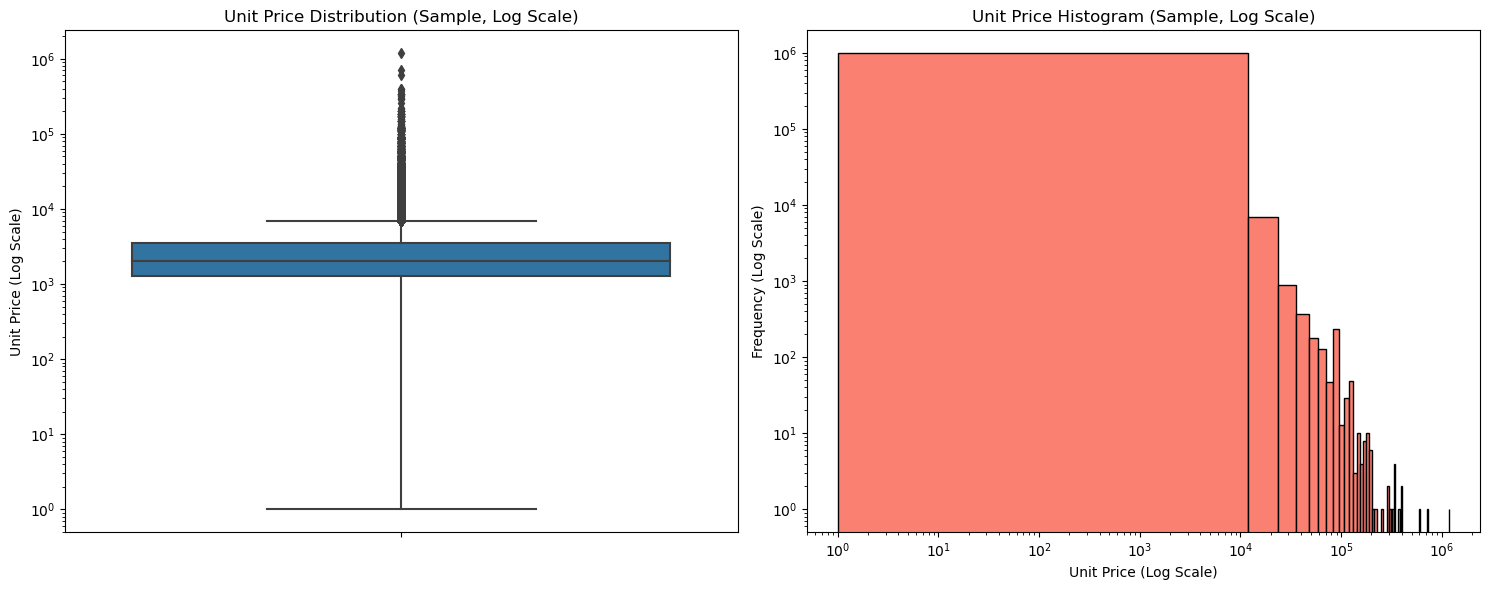

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("객단가 계산 및 분포 확인을 시작합니다...")

# 1. 객단가 계산 (메모리 절약을 위해 float32 사용, 0으로 나누기 방지)
df_pos['객단가'] = (df_pos['매출금액'] / df_pos['매출수량'].replace(0, np.nan)).astype('float32')

# 2. 수치 요약
print("\n--- 객단가(Unit Price) 수치 요약 ---")
print(df_pos['객단가'].describe(percentiles=[.25, .5, .75, .95, .99, .999, .9999]))

# 3. 극단적 객단가 상위 20개 확인 (데이터 입력 오류 탐색용)
print("\n--- 객단가 상위 20개 항목 (고가 상품 혹은 오류 확인) ---")
top_prices = df_pos[['상품명', '상품대분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(20)
display(top_prices)

# 4. 시각화 (메모리 보호를 위해 100만 건 샘플링)
print("\n시각화를 생성 중입니다...")
df_sample = df_pos['객단가'].sample(n=min(1000000, len(df_pos)), random_state=2026).dropna()

plt.figure(figsize=(15, 6))

# (1) Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=df_sample)
plt.yscale('log')
plt.title('Unit Price Distribution (Sample, Log Scale)')
plt.ylabel('Unit Price (Log Scale)')

# (2) Histogram
plt.subplot(1, 2, 2)
plt.hist(df_sample, bins=100, color='salmon', edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.title('Unit Price Histogram (Sample, Log Scale)')
plt.xlabel('Unit Price (Log Scale)')
plt.ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

## (대분류 = 식품) 거래 데이터만 남겨보기

In [7]:
df_pos['상품대분류명'].value_counts()

상품대분류명
음료         18980113
담배         17536139
과자         13361446
유음료         9061204
미반          6128629
면           4927114
서비스 상품      3390482
냉장          2763114
맥주          2480159
즉석음료        2455038
빵           2203525
전통주         2038669
아이스크림       2028368
일용잡화        1881168
조리빵         1470131
즉석 식품       1250121
약품/의료품      1033635
건강/기호식품      926654
가공식품         760781
위생용품         743745
양주와인         685994
디저트          623141
안주           580617
H&B          574090
신선           539930
가정용품         374757
문구/완구        364830
미용/화장품       272167
간식           191805
패션잡화         171661
조미료/건물       135300
냉동           106772
미디어 상품        41771
공병공박스          1976
기타               24
소모품               1
Name: count, dtype: int64

In [8]:
# 1. 상품대분류명 공백 제거
print("상품대분류명 공백 제거 중...")
df_pos['상품대분류명'] = df_pos['상품대분류명'].str.strip()

# 2. 필터링할 식품 카테고리 리스트
food_categories = [
    '음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주', 
    '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트', 
    '안주', '신선', '간식', '조미료/건물', '냉동'
]

# 3. 식품 데이터만 추출하여 df_pos_food에 담기
print("식품 카테고리 필터링 중...")
df_pos_food = df_pos[df_pos['상품대분류명'].isin(food_categories)].copy()

# 4. 결과 확인
print(f"\n전체 데이터 행 수: {len(df_pos):,}")
print(f"식품 카테고리 필터링 후 행 수: {len(df_pos_food):,}")
print(f"제거된 행 수: {len(df_pos) - len(df_pos_food):,}")

display(df_pos_food.head())

# 5. 메모리 관리 안내
# 필터링 후 원본 df_pos가 더 이상 필요 없다면 아래 주석을 해제하여 메모리를 확보하세요.
import gc
del df_pos
gc.collect()

상품대분류명 공백 제거 중...
식품 카테고리 필터링 중...

전체 데이터 행 수: 100,085,071
식품 카테고리 필터링 후 행 수: 73,698,625
제거된 행 수: 26,386,446


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키,객단가
14,20250523,84822,12611,1,13164,202316,1.0,1000.0,오리온)제주용암수530ml,음료,생수,500ml이하,2025-05-23 08:48:22,5,21,23,8,금,12611_1_13164,1000.0
15,20250523,143425,17796,1,59106,117969,1.0,1200.0,오리온)고소미70g,과자,비스킷류,크래커,2025-05-23 14:34:25,5,21,23,14,금,17796_1_59106,1200.0
16,20250523,145747,54630,2,3156,124518,1.0,1200.0,오리온)코코망고알맹이67g,과자,젤리류,국산젤리,2025-05-23 14:57:47,5,21,23,14,금,54630_2_3156,1200.0
17,20250523,165556,18467,1,491,116368,1.0,1700.0,오리온)꼬북칩콘스프맛80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,18467_1_491,1700.0
18,20250523,165556,18467,1,491,117048,1.0,1700.0,오리온)태양의맛썬핫스파이시80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,18467_1_491,1700.0


71515

In [9]:
# 1. 카테고리별 요약 통계 (매출금액, 매출수량, 객단가)
print("카테고리별 요약 통계를 계산 중입니다... (데이터가 커서 시간이 소요될 수 있습니다)")

# 요약 통계량 확인 (평균, 최대값, 99% 지점 등)
category_summary = df_pos_food.groupby('상품대분류명')[['매출금액', '매출수량', '객단가']].agg(['mean', 'max', 'std', lambda x: x.quantile(0.99)])
category_summary.columns = [f"{col}_{stat}" for col, stat in [('매출금액','mean'), ('매출금액','max'), ('매출금액','std'), ('매출금액','99%'), 
                                                       ('매출수량','mean'), ('매출수량','max'), ('매출수량','std'), ('매출수량','99%'),
                                                       ('객단가','mean'), ('객단가','max'), ('객단가','std'), ('객단가','99%')]]

display(category_summary)

# 2. 카테고리별 객단가 상위 5개 상품 확인 (이상치 판단용)
print("\n--- 카테고리별 객단가 상위 상품 리스트 (데이터 오류 확인) ---")

for cat in food_categories:
    print(f"\n[카테고리: {cat}]")
    # 해당 카테고리 추출
    subset = df_pos_food[df_pos_food['상품대분류명'] == cat]
    
    # 객단가 기준 내림차순 상위 5개
    top_items = subset[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(5)
    display(top_items)

print("\n모든 카테고리 확인이 완료되었습니다. 위 리스트를 보고 비상식적인 가격(예: 껌 한 통에 100만원 등)을 가진 카테고리와 상품을 선별하세요.")

카테고리별 요약 통계를 계산 중입니다... (데이터가 커서 시간이 소요될 수 있습니다)


,매출금액_mean,매출금액_max,매출금액_std,매출금액_99%,매출수량_mean,매출수량_max,매출수량_std,매출수량_99%,객단가_mean,객단가_max,객단가_std,객단가_99%
상품대분류명,,,,,,,,,,,,
가공식품,3980.615967,2.897100e+07,9.736681e+04,12600.0,1.304166,999.0,3.884741,4.0,3180.925537,76900.0,1892.555570,8900.0
간식,3392.411865,2.520000e+05,1.864179e+03,7000.0,0.970204,72.0,0.472518,2.0,3507.198242,5900.0,786.496735,5700.0
건강/기호식품,4476.370605,1.177600e+07,2.070075e+04,21200.0,1.764192,484.0,2.177333,8.0,2800.564697,132000.0,2615.365255,12500.0
과자,2047.946533,2.997000e+07,1.203996e+04,8000.0,1.138092,999.0,1.470078,4.0,1868.450439,104000.0,1270.055068,6000.0
냉동,5600.318359,5.283600e+06,3.366088e+04,15600.0,1.042033,60.0,0.822910,3.0,5428.339844,235000.0,5850.030415,11929.0
냉장,2998.757080,3.725200e+06,5.231665e+03,9900.0,1.235763,383.0,1.036920,3.0,2644.668213,100000.0,1403.731362,9000.0
디저트,3159.396240,6.262000e+05,3.701170e+03,16000.0,1.192566,210.0,1.066152,4.0,2678.081787,49000.0,1676.220069,4900.0
맥주,6316.144043,2.322600e+06,9.136185e+03,23450.0,1.917796,600.0,2.422798,6.0,3806.499023,65000.0,3017.021905,18000.0
면,1723.754883,8.400000e+05,1.703342e+03,5600.0,1.118275,570.0,1.087479,3.0,1569.123535,31000.0,665.187657,4750.0



--- 카테고리별 객단가 상위 상품 리스트 (데이터 오류 확인) ---

[카테고리: 음료]


,상품명,상품중분류명,매출수량,매출금액,객단가
11159567,칠성)플레이모빌패키지,탄산음료,1.0,59000.0,59000.0
20233069,HK)헛개컨디션100ml(10입),기능성드링크,1.0,50000.0,50000.0
2542047,CJ)한뿌리홍삼대보100ml10입,선물세트,1.0,50000.0,50000.0
82501202,CJ)한뿌리홍삼대보100ml10입,선물세트,1.0,50000.0,50000.0
72884237,CJ)한뿌리흑삼아르기닌100ml(10입),기능성드링크,1.0,50000.0,50000.0



[카테고리: 과자]


...


[카테고리: 조미료/건물]


,상품명,상품중분류명,매출수량,매출금액,객단가
59272658,25추_올가)참기름간장선물세트2호,선물세트,4.0,356000.0,89000.000000
61582438,25추_코주부)프리미엄육포세트600g,선물세트,11.0,850040.0,77276.367188
3191135,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000
44541803,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000
28114280,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,-1.0,-77000.0,77000.000000



[카테고리: 냉동]


,상품명,상품중분류명,매출수량,매출금액,객단가
92122103,한우 갈비 명품세트 3.2kg,신선냉동,1.0,235000.0,235000.0
49058944,한우 갈비 명품세트 3.2kg,신선냉동,1.0,235000.0,235000.0
39484163,25설)한우갈비 1호 3.2kg,신선냉동,1.0,218000.0,218000.0
12251409,25설)한우갈비 1호 3.2kg,신선냉동,1.0,218000.0,218000.0
72438023,한우 갈비 명품세트 3.2kg,신선냉동,1.0,196500.0,196500.0



모든 카테고리 확인이 완료되었습니다. 위 리스트를 보고 비상식적인 가격(예: 껌 한 통에 100만원 등)을 가진 카테고리와 상품을 선별하세요.


### 추가적으로 확인해볼 것.

- 각 카테고리별로 매출수량 이상치 (Q3 초과)
- 객단가 평균이 높은 대분류 카테고리 5개 -> 여기서 이상치 제거

In [10]:
# 1. 카테고리별 매출수량 이상치 (Q3 초과) 확인
print("[분석 1] 각 카테고리별 매출수량 Q3 초과 데이터 확인 중...")

# 카테고리별 매출수량 Q3 계산
qty_q3_series = df_pos_food.groupby('상품대분류명')['매출수량'].quantile(0.75)

for cat in food_categories:
    q3_val = qty_q3_series[cat]
    # 해당 카테고리에서 Q3를 초과하는 데이터 추출
    qty_outliers = df_pos_food[(df_pos_food['상품대분류명'] == cat) & (df_pos_food['매출수량'] > q3_val)]
    
    if len(qty_outliers) > 0:
        print(f"\n[카테고리: {cat}] 매출수량 Q3({q3_val}) 초과 건수: {len(qty_outliers):,}건")
        # 수량 기준 내림차순 상위 5개 출력
        display(qty_outliers[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='매출수량', ascending=False).head(5))

print("\n" + "="*50 + "\n")

# 2. 객단가 평균 상위 5개 카테고리 내 객단가 이상치 확인
print("[분석 2] 객단가 평균 상위 5개 카테고리 및 객단가 Q3 초과 상품 확인 중...")

# 객단가 평균이 높은 상위 5개 카테고리 추출
top_5_cats = df_pos_food.groupby('상품대분류명')['객단가'].mean().sort_values(ascending=False).head(5).index.tolist()
print(f"객단가 평균 상위 5개 카테고리: {top_5_cats}")

for cat in top_5_cats:
    subset = df_pos_food[df_pos_food['상품대분류명'] == cat]
    q3_price = subset['객단가'].quantile(0.75)
    
    # 해당 카테고리에서 객단가 Q3를 초과하는 데이터 추출
    price_outliers = subset[subset['객단가'] > q3_price]
    
    print(f"\n[카테고리: {cat}] 객단가 Q3({q3_price:,.0f}원) 초과 건수: {len(price_outliers):,}건")
    # 객단가 기준 내림차순 상위 5개 출력
    display(price_outliers[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(5))

print("\n모든 확인이 완료되었습니다. 위 리스트의 상품명과 가격을 보고 실제 이상치 제거 임계치를 결정하세요.")

[분석 1] 각 카테고리별 매출수량 Q3 초과 데이터 확인 중...

[카테고리: 음료] 매출수량 Q3(2.0) 초과 건수: 1,294,508건


,상품명,상품중분류명,매출수량,매출금액,객단가
53381022,칠성)아이시스에코2L,생수,1200.0,2160000.0,1800.0
12593691,PB)내몸애70% 500ml,생수,999.0,249750.0,250.0
12593688,PB)내몸애70% 500ml,생수,999.0,249750.0,250.0
9610024,PB)내몸애70% 500ml,생수,999.0,249750.0,250.0
9611171,PB)내몸애70% 500ml,생수,999.0,249750.0,250.0



[카테고리: 과자] 매출수량 Q3(1.0) 초과 건수: 1,778,469건


,상품명,상품중분류명,매출수량,매출금액,객단가
76659067,1테디베어)인형기획,비스킷류,999.0,29970000.0,30000.0
13156857,PB)숏다리오잉70g,스낵류,999.0,1698300.0,1700.0
16267354,마즈)스니커즈픽앤믹스20g,초콜릿,666.0,466200.0,700.0
81170392,델토리)스웨디시스타일딸기홀릭47g,초콜릿,475.0,1662500.0,3500.0
25802285,농심)츄파춥스300,캔디류,473.0,141900.0,300.0



[카테고리: 유음료] 매출수량 Q3(1.0) 초과 건수: 2,030,734건


...


[카테고리: 맥주] 객단가 Q3(3,600원) 초과 건수: 601,452건


,상품명,상품중분류명,매출수량,매출금액,객단가
66157622,APP)롱보드라거캔24입,수입맥주,1.0,65000.0,65000.0
52025801,APP)롱보드라거캔24입,수입맥주,-1.0,-65000.0,65000.0
96795696,APP)롱보드라거캔24입,수입맥주,1.0,65000.0,65000.0
94678943,APP)런던프라이드330ml병(24입),수입맥주,1.0,64800.0,64800.0
61086096,APP)기네스콜드브루440ml(24입),수입맥주,-4.0,-252000.0,63000.0



[카테고리: 간식] 객단가 Q3(3,900원) 초과 건수: 22,958건


,상품명,상품중분류명,매출수량,매출금액,객단가
53976418,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
53517297,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
87674727,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
35206744,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
59602565,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0



모든 확인이 완료되었습니다. 위 리스트의 상품명과 가격을 보고 실제 이상치 제거 임계치를 결정하세요.


객단가 상위 5개의 객단가 99% 초과인 상품들 확인

In [11]:
for cat in top_5_cats:
    subset = df_pos_food[df_pos_food['상품대분류명'] == cat]
    q99_price = subset['객단가'].quantile(0.99)
    
    # 해당 카테고리에서 객단가 Q99를 초과하는 데이터 추출
    price_outliers = subset[subset['객단가'] > q99_price]
    
    print(f"\n[카테고리: {cat}] 객단가 Q99({q99_price:,.0f}원) 초과 건수: {len(price_outliers):,}건")
    # 객단가 기준 내림차순 상위 5개 출력
    display(price_outliers[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(5))



[카테고리: 양주와인] 객단가 Q99(119,900원) 초과 건수: 6,603건


,상품명,상품중분류명,매출수량,매출금액,객단가
46820616,윌리엄)글렌피딕 40년,양주,-100.0,-1.300000e+09,13000000.0
46820615,윌리엄)글렌피딕 40년,양주,100.0,1.300000e+09,13000000.0
46820580,윌리엄)글렌피딕 40년,양주,100.0,1.300000e+09,13000000.0
46820579,윌리엄)글렌피딕 40년,양주,-100.0,-1.300000e+09,13000000.0
12016098,윌리엄)글렌피딕30년,양주,-1.0,-1.400000e+06,1400000.0



[카테고리: 냉동] 객단가 Q99(11,929원) 초과 건수: 1,068건


,상품명,상품중분류명,매출수량,매출금액,객단가
92122103,한우 갈비 명품세트 3.2kg,신선냉동,1.0,235000.0,235000.0
49058944,한우 갈비 명품세트 3.2kg,신선냉동,1.0,235000.0,235000.0
12251409,25설)한우갈비 1호 3.2kg,신선냉동,1.0,218000.0,218000.0
39484163,25설)한우갈비 1호 3.2kg,신선냉동,1.0,218000.0,218000.0
72438023,한우 갈비 명품세트 3.2kg,신선냉동,1.0,196500.0,196500.0



[카테고리: 안주] 객단가 Q99(14,900원) 초과 건수: 5,365건


,상품명,상품중분류명,매출수량,매출금액,객단가
28109267,CJ)맛밤(10입)420g,농산안주,-1.0,-22900.0,22900.0
26714937,CJ)맛밤(10입)420g,농산안주,1.0,22900.0,22900.0
25273617,CJ)맛밤(10입)420g,농산안주,1.0,22900.0,22900.0
66533953,CJ)맛밤(10입)420g,농산안주,1.0,22900.0,22900.0
31964745,CJ)맛밤(10입)420g,농산안주,-1.0,-22900.0,22900.0



[카테고리: 맥주] 객단가 Q99(18,000원) 초과 건수: 20,069건


,상품명,상품중분류명,매출수량,매출금액,객단가
52025801,APP)롱보드라거캔24입,수입맥주,-1.0,-65000.0,65000.0
96795696,APP)롱보드라거캔24입,수입맥주,1.0,65000.0,65000.0
66157622,APP)롱보드라거캔24입,수입맥주,1.0,65000.0,65000.0
94678943,APP)런던프라이드330ml병(24입),수입맥주,1.0,64800.0,64800.0
61086096,APP)기네스콜드브루440ml(24입),수입맥주,-4.0,-252000.0,63000.0



[카테고리: 간식] 객단가 Q99(5,700원) 초과 건수: 57건


,상품명,상품중분류명,매출수량,매출금액,객단가
1479411,MDS)옥수수콘치즈255g,냉장피자,-1.0,-5900.0,5900.0
65746450,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
66989414,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
71220579,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0
71876024,MDS)옥수수콘치즈255g,냉장피자,1.0,5900.0,5900.0


#### 결론:

- 각 대분류 카테고리별로 '매출수량' 이상치(Q3 초과)인 데이터 제거
- 객단가 높은 대분류 카테고리 상위 5개에서 '객단가' Q(99%) 초과인 데이터 제거

In [12]:
# 1. 각 카테고리별 매출수량 Q3 및 객단가 Q99 계산
print("그룹별 임계치(Q3, Q99) 계산 중...")
qty_q3_dict = df_pos_food.groupby('상품대분류명')['매출수량'].quantile(0.75).to_dict()
price_q99_dict = df_pos_food.groupby('상품대분류명')['객단가'].quantile(0.99).to_dict()

# 2. 객단가 평균 상위 5개 카테고리 식별
top_5_cats = df_pos_food.groupby('상품대분류명')['객단가'].mean().sort_values(ascending=False).head(5).index.tolist()
print(f"객단가 상위 5개 카테고리 (Q99 적용 대상): {top_5_cats}")

# 3. 필터링 수행
print(f"\n필터링 전 데이터 건수: {len(df_pos_food):,}")

# 조건 1: 매출수량 <= Q3 (전체 카테고리 공통 적용)
mask_qty = df_pos_food['매출수량'] <= df_pos_food['상품대분류명'].map(qty_q3_dict)

# 조건 2: 상위 5개 카테고리에 대해서만 객단가 <= Q99 적용
# (해당 카테고리이면서 Q99 초과인 데이터만 제외하는 마스크)
mask_price = ~(df_pos_food['상품대분류명'].isin(top_5_cats) & (df_pos_food['객단가'] > df_pos_food['상품대분류명'].map(price_q99_dict)))

# 최종 필터링
df_pos_food_final = df_pos_food[mask_qty & mask_price].copy()

print(f"최종 필터링 후 데이터 건수: {len(df_pos_food_final):,}")
print(f"제거된 총 행 수: {len(df_pos_food) - len(df_pos_food_final):,}")
print(f"데이터 감소율: {(1 - len(df_pos_food_final)/len(df_pos_food))*100:.2f}%")

# 4. 결과 확인
display(df_pos_food_final.head())

# 메모리 확보를 위해 중간 데이터 삭제 (필요시)
del df_pos_food
import gc
gc.collect()

그룹별 임계치(Q3, Q99) 계산 중...
객단가 상위 5개 카테고리 (Q99 적용 대상): ['양주와인', '냉동', '안주', '맥주', '간식']

필터링 전 데이터 건수: 73,698,625
최종 필터링 후 데이터 건수: 64,995,080
제거된 총 행 수: 8,703,545
데이터 감소율: 11.81%


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키,객단가
14,20250523,84822,12611,1,13164,202316,1.0,1000.0,오리온)제주용암수530ml,음료,생수,500ml이하,2025-05-23 08:48:22,5,21,23,8,금,12611_1_13164,1000.0
15,20250523,143425,17796,1,59106,117969,1.0,1200.0,오리온)고소미70g,과자,비스킷류,크래커,2025-05-23 14:34:25,5,21,23,14,금,17796_1_59106,1200.0
16,20250523,145747,54630,2,3156,124518,1.0,1200.0,오리온)코코망고알맹이67g,과자,젤리류,국산젤리,2025-05-23 14:57:47,5,21,23,14,금,54630_2_3156,1200.0
17,20250523,165556,18467,1,491,116368,1.0,1700.0,오리온)꼬북칩콘스프맛80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,18467_1_491,1700.0
18,20250523,165556,18467,1,491,117048,1.0,1700.0,오리온)태양의맛썬핫스파이시80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,18467_1_491,1700.0


0

In [13]:
# 저장
output_file_path = 'pos_data_food_final_상품단위변환전.parquet'

print(f"데이터를 {output_file_path}로 저장 중입니다. 잠시만 기다려 주세요...")
try:
    # index=False로 설정하여 불필요한 인덱스 컬럼 저장을 방지
    df_pos_food_final.to_parquet(output_file_path, engine='pyarrow', index=False)
    print(f"저장 완료! 파일 경로: {output_file_path}")

except Exception as e:
   print(f"저장 중 오류가 발생했습니다: {e}")

데이터를 pos_data_food_final_상품단위변환전.parquet로 저장 중입니다. 잠시만 기다려 주세요...
저장 완료! 파일 경로: pos_data_food_final_상품단위변환전.parquet


## 상품 단위로 데이터셋 변환